# FinSmart — FinBot, Behavior Neural Network, dan Sistem Rekomendasi
**Muhammad Syaiful**

---

| No | Bagian | Section |
|----|--------|---------|
| 1 | Install dan Import Library | Section 1 |
| 2 | Load Dataset Behavior | Section 2 |
| 3 | FinBot — Intent dan Database Respons | Section 3 |
| 4 | Kelas FinBot | Section 4 |
| 5 | Uji FinBot | Section 5 |
| 6 | Financial Behavior — Neural Network TensorFlow | Section 6 |
| 7 | Training Neural Network Behavior | Section 7 |
| 8 | Evaluasi Model Behavior | Section 8 |
| 9 | FinSmartBehaviorInference Class | Section 9 |
| 10 | Uji Inference Behavior | Section 10 |
| 11 | Sistem Rekomendasi Kesiapan Investasi | Section 11 |
| 12 | Uji Sistem Rekomendasi | Section 12 |
| 13 | Dokumentasi Arsitektur Pipeline AI | Section 13 |
| 14 | Ringkasan | Section 14 |

## 1. Install dan Import Library

In [1]:
!pip install transformers torch scikit-learn tensorflow -q

print("Instalasi selesai")

Instalasi selesai


In [2]:
import numpy as np
import pandas as pd
import json
import os
import pickle
import joblib
import matplotlib.pyplot as plt
from transformers import pipeline
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(f"TensorFlow versi : {tf.__version__}")
print("Semua library berhasil diimport")

TensorFlow versi : 2.20.0
Semua library berhasil diimport


## 2. Load Dataset Behavior

In [3]:
df = pd.read_csv("dataset_financial_behavior.csv")

print(f"Shape dataset : {df.shape}")
print(f"Kolom         : {list(df.columns)}")
print(f"Distribusi Tipe:")
print(df["Tipe"].value_counts())
df.head()

Shape dataset : (16000, 7)
Kolom         : ['Income', 'Needs', 'Wants', 'Savings', 'Total_Spending', 'Financial_Balance', 'Tipe']
Distribusi Tipe:
Tipe
normal    5462
boros     5344
hemat     5194
Name: count, dtype: int64


,Income,Needs,Wants,Savings,Total_Spending,Financial_Balance,Tipe
0,36085000.0,20344000.0,12443000.0,4950000.0,32787000.0,3298000.0,normal
1,4979000.0,3365000.0,1317000.0,1062000.0,4682000.0,297000.0,hemat
2,89485000.0,56083000.0,17515000.0,24775000.0,73598000.0,15887000.0,hemat
3,77968000.0,42767000.0,25103000.0,14771000.0,67870000.0,10098000.0,normal
4,31911000.0,16440000.0,17908000.0,2300000.0,34348000.0,-2437000.0,boros


## 3. FinBot — Definisi Intent dan Database Respons

FinBot menggunakan pendekatan Zero-Shot Classification dari Hugging Face untuk mendeteksi intent dari pertanyaan pengguna dalam bahasa Indonesia.

In [4]:
import warnings
warnings.filterwarnings("ignore")

print("Loading model Hugging Face, harap tunggu...")

finbot_classifier = pipeline(
    task="zero-shot-classification",
    model="facebook/bart-large-mnli"
)

print("Model Hugging Face berhasil diload")

Loading model Hugging Face, harap tunggu...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model Hugging Face berhasil diload


In [5]:
INTENT_LABELS = [
    "tips menabung",
    "cara mengatur anggaran",
    "kategori pengeluaran",
    "investasi untuk pemula",
    "cara mengurangi pengeluaran",
    "target tabungan",
    "rekomendasi keuangan",
    "pengertian literasi keuangan",
]

RESPONSE_DATABASE = {
    "tips menabung": (
        "Tips Menabung yang Efektif:\n"
        "1. Terapkan metode 50/30/20 — 50% kebutuhan, 30% keinginan, 20% tabungan.\n"
        "2. Simpan di awal bulan sebelum digunakan (pay yourself first).\n"
        "3. Buat rekening tabungan terpisah dari rekening harian.\n"
        "4. Mulai dari nominal kecil tapi konsisten — Rp 50.000/hari = Rp 1,5 juta/bulan.\n"
        "5. Gunakan fitur Target Tabungan di FinSmart untuk pantau progres kamu."
    ),
    "cara mengatur anggaran": (
        "Cara Mengatur Anggaran Bulanan:\n"
        "1. Catat semua pemasukan bulanan terlebih dahulu.\n"
        "2. Bagi pengeluaran ke kategori: Makanan, Transport, Tagihan, Hiburan, dll.\n"
        "3. Tentukan batas maksimal untuk setiap kategori.\n"
        "4. Pantau pengeluaran harian agar tidak melebihi batas.\n"
        "5. FinSmart dapat mengingatkan kamu saat mendekati batas anggaran."
    ),
    "kategori pengeluaran": (
        "Kategori Pengeluaran di FinSmart:\n"
        "FinSmart mengklasifikasikan transaksi ke 9 kategori:\n"
        "1. Food & Dining | 2. Transportation | 3. Shopping | 4. Groceries\n"
        "5. Bills & Utilities | 6. Entertainment | 7. Health | 8. Education | 9. Others\n\n"
        "Kategori ditentukan otomatis oleh AI saat kamu input transaksi."
    ),
    "investasi untuk pemula": (
        "Panduan Investasi untuk Pemula:\n"
        "Sebelum investasi, pastikan sudah:\n"
        "- Punya dana darurat (3-6x pengeluaran bulanan)\n"
        "- Tidak punya hutang konsumtif\n"
        "- Tabungan rutin sudah berjalan\n\n"
        "Pilihan investasi untuk pemula:\n"
        "- Reksa Dana Pasar Uang — risiko rendah, cocok untuk pemula\n"
        "- Deposito — aman, bunga pasti\n"
        "- Obligasi Negara (ORI/SBR) — dijamin pemerintah\n\n"
        "Cek fitur Kesiapan Investasi di FinSmart untuk analisis profil keuanganmu."
    ),
    "cara mengurangi pengeluaran": (
        "Tips Mengurangi Pengeluaran:\n"
        "1. Identifikasi kategori pengeluaran terbesar dari dashboard FinSmart.\n"
        "2. Bedakan kebutuhan (harus) vs keinginan (bisa ditunda).\n"
        "3. Kurangi frekuensi makan di luar — masak sendiri bisa hemat 60%.\n"
        "4. Manfaatkan promo dan cashback saat belanja online.\n"
        "5. Batalkan langganan yang jarang dipakai."
    ),
    "target tabungan": (
        "Cara Menetapkan Target Tabungan:\n"
        "1. Tentukan tujuan spesifik: liburan, DP rumah, dana darurat, dll.\n"
        "2. Hitung nominal yang dibutuhkan dan tenggat waktunya.\n"
        "3. Bagi dengan jumlah bulan untuk mendapatkan target bulanan.\n"
        "4. Set target di fitur Sistem Anggaran FinSmart.\n"
        "5. FinSmart akan memberi notifikasi jika kamu on-track."
    ),
    "rekomendasi keuangan": (
        "Rekomendasi Keuangan Personal:\n"
        "Berdasarkan data keuanganmu, FinSmart memberikan rekomendasi:\n"
        "- Analisis pola pengeluaran bulanan\n"
        "- Kategori mana yang paling banyak menguras anggaran\n"
        "- Rekomendasi batas anggaran per kategori\n\n"
        "Masuk ke menu Analisis dan Rekomendasi AI untuk melihat insight personalmu."
    ),
    "pengertian literasi keuangan": (
        "Apa itu Literasi Keuangan?\n"
        "Literasi keuangan adalah kemampuan memahami dan menggunakan\n"
        "berbagai konsep keuangan secara efektif, meliputi:\n"
        "- Mengelola pendapatan dan pengeluaran\n"
        "- Merencanakan tabungan dan investasi\n"
        "- Memahami produk keuangan (kredit, asuransi, investasi)\n"
        "- Membuat keputusan keuangan yang bijak\n\n"
        "Data OJK 2024: literasi keuangan generasi muda Indonesia masih di bawah 50%."
    ),
}

RESPONSE_DEFAULT = (
    "Maaf, saya belum bisa menjawab pertanyaan tersebut.\n"
    "Kamu bisa tanya tentang: tips menabung, mengatur anggaran, "
    "kategori pengeluaran, investasi pemula, atau target tabungan."
)

print(f"Database FinBot siap: {len(RESPONSE_DATABASE)} intent terdaftar")

Database FinBot siap: 8 intent terdaftar


## 4. Kelas FinBot

Kelas `FinBot` mengelola alur deteksi intent dan pengembalian respons. Setiap percakapan disimpan dalam `chat_history` untuk keperluan logging.

In [6]:
class FinBot:
    """
    Chatbot keuangan FinSmart berbasis Hugging Face Zero-Shot Classification.

    Alur kerja:
    1. Terima pertanyaan pengguna
    2. Deteksi intent menggunakan Zero-Shot Classification
    3. Kembalikan respons sesuai intent yang terdeteksi
    """

    def __init__(self, classifier, intent_labels, response_db, threshold=0.10):
        self.classifier    = classifier
        self.intent_labels = intent_labels
        self.response_db   = response_db
        self.threshold     = threshold
        self.chat_history  = []

    def detect_intent(self, pertanyaan: str) -> tuple:
        result     = self.classifier(
            pertanyaan,
            candidate_labels=self.intent_labels,
            hypothesis_template="Pertanyaan ini tentang {}."
        )
        top_intent = result["labels"][0]
        top_score  = result["scores"][0]
        return top_intent, top_score

    def chat(self, pertanyaan: str) -> dict:
        pertanyaan = pertanyaan.strip()
        if not pertanyaan:
            return {"error": "Pertanyaan tidak boleh kosong."}

        intent, confidence = self.detect_intent(pertanyaan)

        if confidence >= self.threshold:
            respons = self.response_db.get(intent, RESPONSE_DEFAULT)
        else:
            respons = RESPONSE_DEFAULT
            intent  = "tidak_terdeteksi"

        entry = {
            "pertanyaan" : pertanyaan,
            "intent"     : intent,
            "confidence" : round(confidence * 100, 2),
            "respons"    : respons,
        }
        self.chat_history.append(entry)
        return entry

    def tampilkan_respons(self, result: dict):
        print("=" * 60)
        print(f"Pertanyaan : {result['pertanyaan']}")
        print(f"Intent     : {result['intent']} ({result['confidence']}%)")
        print("-" * 60)
        print(f"FinBot     :\n{result['respons']}")
        print("=" * 60)


finbot = FinBot(
    classifier    = finbot_classifier,
    intent_labels = INTENT_LABELS,
    response_db   = RESPONSE_DATABASE,
    threshold     = 0.10
)

print("FinBot berhasil diinisialisasi")

FinBot berhasil diinisialisasi


## 5. Uji FinBot

In [7]:
pertanyaan_uji = [
    "Gimana cara biar bisa nabung lebih banyak tiap bulan?",
    "Aku mau mulai investasi tapi masih pemula, harus mulai dari mana?",
    "Pengeluaran buat makan di luar aku besar banget, gimana nguranginnya?",
    "Aplikasi ini bisa klasifikasi pengeluaran apa aja?",
    "Aku mau nabung buat liburan tahun depan, target 10 juta",
]

for pertanyaan in pertanyaan_uji:
    hasil = finbot.chat(pertanyaan)
    finbot.tampilkan_respons(hasil)
    print()

Pertanyaan : Gimana cara biar bisa nabung lebih banyak tiap bulan?
Intent     : rekomendasi keuangan (15.88%)
------------------------------------------------------------
FinBot     :
Rekomendasi Keuangan Personal:
Berdasarkan data keuanganmu, FinSmart memberikan rekomendasi:
- Analisis pola pengeluaran bulanan
- Kategori mana yang paling banyak menguras anggaran
- Rekomendasi batas anggaran per kategori

Masuk ke menu Analisis dan Rekomendasi AI untuk melihat insight personalmu.

Pertanyaan : Aku mau mulai investasi tapi masih pemula, harus mulai dari mana?
Intent     : investasi untuk pemula (23.45%)
------------------------------------------------------------
FinBot     :
Panduan Investasi untuk Pemula:
Sebelum investasi, pastikan sudah:
- Punya dana darurat (3-6x pengeluaran bulanan)
- Tidak punya hutang konsumtif
- Tabungan rutin sudah berjalan

Pilihan investasi untuk pemula:
- Reksa Dana Pasar Uang — risiko rendah, cocok untuk pemula
- Deposito — aman, bunga pasti
- Obligasi Neg

In [8]:
with open("finbot_chat_history.json", "w", encoding="utf-8") as f:
    json.dump(finbot.chat_history, f, ensure_ascii=False, indent=2)

print(f"Chat history disimpan: finbot_chat_history.json ({len(finbot.chat_history)} percakapan)")

Chat history disimpan: finbot_chat_history.json (5 percakapan)


## 6. Financial Behavior — Neural Network TensorFlow

Model klasifikasi perilaku keuangan (Hemat / Normal / Boros) dibangun menggunakan TensorFlow Functional API. Dataset yang digunakan adalah `dataset_financial_behavior.csv` dari tim Data Scientist dengan 16.000 baris dan 6 fitur.

**Fitur input**: Income, Needs, Wants, Savings, Total_Spending, Financial_Balance

**Target**: Tipe (hemat / normal / boros)

In [9]:
FITUR_BEHAVIOR = ["Income", "Needs", "Wants", "Savings", "Total_Spending", "Financial_Balance"]
TARGET_BEHAVIOR = "Tipe"

X = df[FITUR_BEHAVIOR].values
y = df[TARGET_BEHAVIOR].values

label_encoder_behavior = LabelEncoder()
y_encoded = label_encoder_behavior.fit_transform(y)
y_onehot  = keras.utils.to_categorical(y_encoded)

scaler_behavior = StandardScaler()
X_scaled = scaler_behavior.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_onehot, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Kelas          : {label_encoder_behavior.classes_}")
print(f"Jumlah fitur   : {X_train.shape[1]}")
print(f"Train samples  : {X_train.shape[0]}")
print(f"Test samples   : {X_test.shape[0]}")

Kelas          : ['boros' 'hemat' 'normal']
Jumlah fitur   : 6
Train samples  : 12800
Test samples   : 3200


## 7. Training Neural Network Behavior

Arsitektur menggunakan TensorFlow Functional API dengan Skip Connection, BatchNormalization, dan Dropout untuk mencegah overfitting. Custom Callback `FinSmartBehaviorCallback` mencatat log training setiap epoch.

In [10]:
class FinSmartBehaviorCallback(keras.callbacks.Callback):
    """
    Custom Callback untuk model Financial Behavior FinSmart.
    Mencatat log training per epoch dan memberi notifikasi saat akurasi target tercapai.
    """

    def __init__(self, target_accuracy=0.85):
        super().__init__()
        self.target_accuracy = target_accuracy
        self.training_log    = []
        self.best_val_acc    = 0.0

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        entry = {
            "epoch"       : epoch + 1,
            "loss"        : round(logs.get("loss", 0), 4),
            "accuracy"    : round(logs.get("accuracy", 0), 4),
            "val_loss"    : round(logs.get("val_loss", 0), 4),
            "val_accuracy": round(logs.get("val_accuracy", 0), 4),
        }
        self.training_log.append(entry)

        if logs.get("val_accuracy", 0) > self.best_val_acc:
            self.best_val_acc = logs.get("val_accuracy", 0)

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d} | "
                  f"loss: {entry['loss']:.4f} | "
                  f"acc: {entry['accuracy']:.4f} | "
                  f"val_acc: {entry['val_accuracy']:.4f}")

        if logs.get("val_accuracy", 0) >= self.target_accuracy:
            print(f"  Target akurasi {self.target_accuracy*100:.0f}% tercapai di epoch {epoch+1}")

    def on_train_end(self, logs=None):
        print(f"\nTraining selesai. Best val_accuracy: {self.best_val_acc:.4f}")


print("FinSmartBehaviorCallback berhasil didefinisikan")

FinSmartBehaviorCallback berhasil didefinisikan


In [11]:
n_fitur  = X_train.shape[1]
n_kelas  = y_onehot.shape[1]

inputs      = Input(shape=(n_fitur,), name="input_behavior")

x           = layers.Dense(128, activation="relu", name="dense_1")(inputs)
x           = layers.BatchNormalization(name="bn_1")(x)
x           = layers.Dropout(0.3, name="dropout_1")(x)

x           = layers.Dense(64, activation="relu", name="dense_2")(x)
x           = layers.BatchNormalization(name="bn_2")(x)
x           = layers.Dropout(0.2, name="dropout_2")(x)

skip        = layers.Dense(64, activation="relu", name="skip_proj")(inputs)
x           = layers.Add(name="skip_connection")([x, skip])

x           = layers.Dense(32, activation="relu", name="dense_3")(x)
x           = layers.Dropout(0.1, name="dropout_3")(x)

outputs     = layers.Dense(n_kelas, activation="softmax", name="output_behavior")(x)

behavior_nn = Model(inputs=inputs, outputs=outputs, name="FinSmartBehaviorNN")

behavior_nn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

behavior_nn.summary()

Model: "FinSmartBehaviorNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_behavior      │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │        896 │ input_behavior[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 64)        │        256 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_proj (Dense)   │ (None, 64)        │        448 │ input_behavior[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_connection     │ (None, 64)        │          0 │ dropout_2[0][0],  │
│ (Add)               │                   │            │ skip_proj[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ skip_connection[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_behavior     │ (None, 3)         │         99 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,547 (49.01 KB)

 Trainable params: 12,163 (47.51 KB)

 Non-trainable params: 384 (1.50 KB)

In [12]:
behavior_callback = FinSmartBehaviorCallback(target_accuracy=0.85)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True
)

model_checkpoint = keras.callbacks.ModelCheckpoint(
    "best_behavior_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=0
)

print("Mulai training Neural Network Behavior...")
print("=" * 65)

history_behavior = behavior_nn.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=64,
    callbacks=[behavior_callback, early_stopping, model_checkpoint],
    verbose=0
)

Mulai training Neural Network Behavior...
  Target akurasi 85% tercapai di epoch 1
  Target akurasi 85% tercapai di epoch 2
  Target akurasi 85% tercapai di epoch 3
  Target akurasi 85% tercapai di epoch 4
  Target akurasi 85% tercapai di epoch 5
  Target akurasi 85% tercapai di epoch 6
  Target akurasi 85% tercapai di epoch 7
  Target akurasi 85% tercapai di epoch 8
  Target akurasi 85% tercapai di epoch 9
  Epoch  10 | loss: 0.2144 | acc: 0.9144 | val_acc: 0.9331
  Target akurasi 85% tercapai di epoch 10
  Target akurasi 85% tercapai di epoch 11
  Target akurasi 85% tercapai di epoch 12
  Target akurasi 85% tercapai di epoch 13
  Target akurasi 85% tercapai di epoch 14
  Target akurasi 85% tercapai di epoch 15
  Target akurasi 85% tercapai di epoch 16
  Target akurasi 85% tercapai di epoch 17
  Target akurasi 85% tercapai di epoch 18
  Target akurasi 85% tercapai di epoch 19
  Epoch  20 | loss: 0.2042 | acc: 0.9195 | val_acc: 0.9319
  Target akurasi 85% tercapai di epoch 20
  Target 

## 8. Evaluasi Model Behavior

In [13]:
y_pred_prob  = behavior_nn.predict(X_test)
y_pred_idx   = np.argmax(y_pred_prob, axis=1)
y_true_idx   = np.argmax(y_test, axis=1)
y_pred_label = label_encoder_behavior.inverse_transform(y_pred_idx)
y_true_label = label_encoder_behavior.inverse_transform(y_true_idx)

test_acc = accuracy_score(y_true_idx, y_pred_idx)

print("=" * 65)
print("EVALUASI MODEL NEURAL NETWORK BEHAVIOR")
print("=" * 65)
print(f"Test Accuracy  : {test_acc * 100:.2f}%")
print()
print(classification_report(y_true_label, y_pred_label,
                            target_names=label_encoder_behavior.classes_))

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
EVALUASI MODEL NEURAL NETWORK BEHAVIOR
Test Accuracy  : 93.66%

              precision    recall  f1-score   support

       boros       0.99      0.97      0.98      1069
       hemat       0.92      0.93      0.92      1039
      normal       0.90      0.91      0.91      1092

    accuracy                           0.94      3200
   macro avg       0.94      0.94      0.94      3200
weighted avg       0.94      0.94      0.94      3200



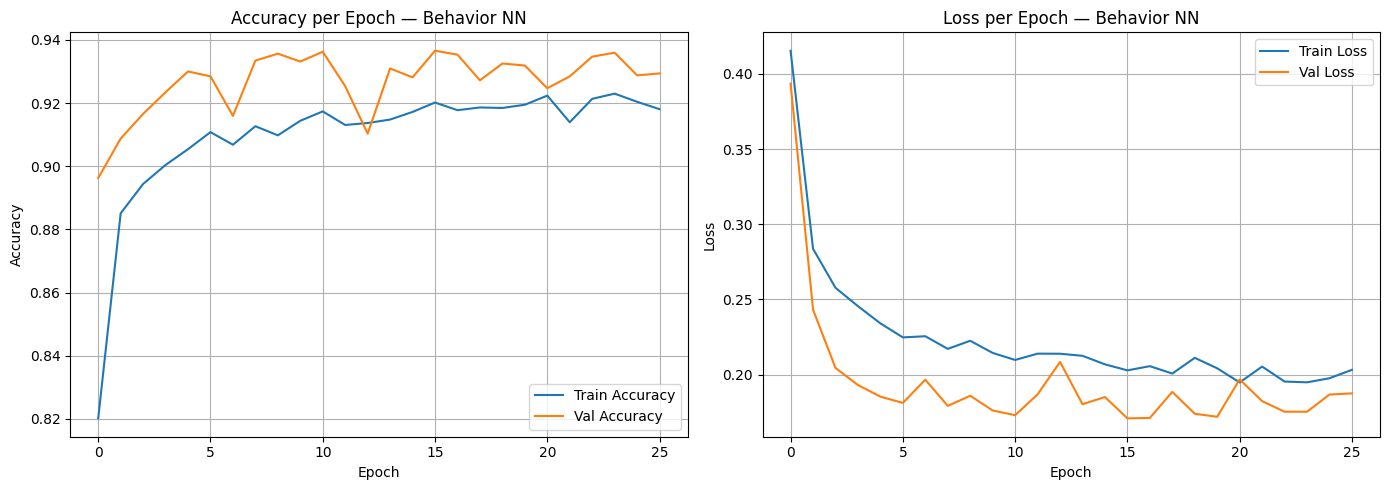

Grafik disimpan: behavior_training_history.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_behavior.history["accuracy"],    label="Train Accuracy")
axes[0].plot(history_behavior.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy per Epoch — Behavior NN")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_behavior.history["loss"],     label="Train Loss")
axes[1].plot(history_behavior.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss per Epoch — Behavior NN")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("behavior_training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik disimpan: behavior_training_history.png")

## 9. Simpan Model dan FinSmartBehaviorInference Class

Model disimpan dalam format `.keras`. Kelas `FinSmartBehaviorInference` digunakan untuk melakukan prediksi dari input mentah (Income, Needs, Wants, Savings).

In [15]:
behavior_nn.save("finsmart_behavior_model.keras")

with open("behavior_label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder_behavior, f)

with open("behavior_scaler.pkl", "wb") as f:
    pickle.dump(scaler_behavior, f)

training_log_behavior = {
    "model"          : "FinSmartBehaviorNN",
    "epochs_run"     : len(behavior_callback.training_log),
    "best_val_acc"   : round(behavior_callback.best_val_acc * 100, 2),
    "test_accuracy"  : round(test_acc * 100, 2),
    "log"            : behavior_callback.training_log,
}

with open("training_log_behavior.json", "w", encoding="utf-8") as f:
    json.dump(training_log_behavior, f, ensure_ascii=False, indent=2)

print("File tersimpan:")
print("  finsmart_behavior_model.keras")
print("  behavior_label_encoder.pkl")
print("  behavior_scaler.pkl")
print("  training_log_behavior.json")

File tersimpan:
  finsmart_behavior_model.keras
  behavior_label_encoder.pkl
  behavior_scaler.pkl
  training_log_behavior.json


In [16]:
class FinSmartBehaviorInference:
    """
    Kelas inference untuk model Neural Network Financial Behavior FinSmart.

    Input  : Income, Needs, Wants, Savings (nilai Rupiah mentah)
    Output : tipe perilaku keuangan (hemat / normal / boros) + confidence
    """

    def __init__(self, model, scaler, label_encoder):
        self.model         = model
        self.scaler        = scaler
        self.label_encoder = label_encoder

    def predict(self, income: float, needs: float, wants: float, savings: float) -> dict:
        total_spending    = needs + wants
        financial_balance = income - total_spending

        X_raw    = np.array([[income, needs, wants, savings, total_spending, financial_balance]])
        X_scaled = self.scaler.transform(X_raw)

        proba    = self.model.predict(X_scaled, verbose=0)[0]
        idx      = int(np.argmax(proba))
        tipe     = self.label_encoder.inverse_transform([idx])[0]

        classes      = self.label_encoder.classes_
        confidence   = {cls: round(float(p) * 100, 2) for cls, p in zip(classes, proba)}

        savings_ratio = savings / income * 100 if income > 0 else 0
        wants_ratio   = wants   / income * 100 if income > 0 else 0
        needs_ratio   = needs   / income * 100 if income > 0 else 0

        return {
            "tipe_keuangan" : tipe,
            "confidence_pct": confidence,
            "rasio": {
                "savings_ratio_pct": round(savings_ratio, 2),
                "wants_ratio_pct"  : round(wants_ratio, 2),
                "needs_ratio_pct"  : round(needs_ratio, 2),
            },
            "interpretasi": {
                "hemat" : "Savings > 20% DAN Wants < 30% — tabungan tinggi, lifestyle terkontrol",
                "normal": "Mendekati prinsip 50/30/20 — pengeluaran dan tabungan relatif seimbang",
                "boros" : "Savings < 20% DAN Wants > 30% — lifestyle tinggi, tabungan rendah",
            }.get(tipe, "-"),
        }


behavior_inference = FinSmartBehaviorInference(
    model         = behavior_nn,
    scaler        = scaler_behavior,
    label_encoder = label_encoder_behavior
)

print("FinSmartBehaviorInference berhasil diinisialisasi")

FinSmartBehaviorInference berhasil diinisialisasi


## 10. Uji Inference Behavior

In [17]:
print("=" * 65)
print("UJI INFERENCE 1: Pengguna Hemat")
print("=" * 65)
hasil_1 = behavior_inference.predict(
    income=5000000, needs=2500000, wants=500000, savings=2000000
)
print(f"Tipe           : {hasil_1['tipe_keuangan']}")
print(f"Confidence     : {hasil_1['confidence_pct']}")
print(f"Savings Ratio  : {hasil_1['rasio']['savings_ratio_pct']}%")
print(f"Interpretasi   : {hasil_1['interpretasi']}")

print()
print("=" * 65)
print("UJI INFERENCE 2: Pengguna Boros")
print("=" * 65)
hasil_2 = behavior_inference.predict(
    income=5000000, needs=2500000, wants=2200000, savings=300000
)
print(f"Tipe           : {hasil_2['tipe_keuangan']}")
print(f"Confidence     : {hasil_2['confidence_pct']}")
print(f"Savings Ratio  : {hasil_2['rasio']['savings_ratio_pct']}%")
print(f"Interpretasi   : {hasil_2['interpretasi']}")

print()
print("=" * 65)
print("UJI INFERENCE 3: Pengguna Normal")
print("=" * 65)
hasil_3 = behavior_inference.predict(
    income=5000000, needs=2500000, wants=1400000, savings=1100000
)
print(f"Tipe           : {hasil_3['tipe_keuangan']}")
print(f"Confidence     : {hasil_3['confidence_pct']}")
print(f"Savings Ratio  : {hasil_3['rasio']['savings_ratio_pct']}%")
print(f"Interpretasi   : {hasil_3['interpretasi']}")

UJI INFERENCE 1: Pengguna Hemat
Tipe           : hemat
Confidence     : {'boros': 0.0, 'hemat': 98.95, 'normal': 1.05}
Savings Ratio  : 40.0%
Interpretasi   : Savings > 20% DAN Wants < 30% — tabungan tinggi, lifestyle terkontrol

UJI INFERENCE 2: Pengguna Boros
Tipe           : boros
Confidence     : {'boros': 64.56, 'hemat': 0.66, 'normal': 34.79}
Savings Ratio  : 6.0%
Interpretasi   : Savings < 20% DAN Wants > 30% — lifestyle tinggi, tabungan rendah

UJI INFERENCE 3: Pengguna Normal
Tipe           : hemat
Confidence     : {'boros': 0.01, 'hemat': 80.01, 'normal': 19.97}
Savings Ratio  : 22.0%
Interpretasi   : Savings > 20% DAN Wants < 30% — tabungan tinggi, lifestyle terkontrol


## 11. Sistem Rekomendasi Kesiapan Investasi

Kelas `RekomendasiInvestasi` menganalisis profil keuangan pengguna berdasarkan dua metrik utama sesuai rumus resmi tim Data Scientist:
- **BLR** (Basic Liquidity Ratio) = Tabungan Total / Total Pengeluaran Bulanan
- **SR** (Savings Ratio) = Tabungan Bulanan / Income Bulanan x 100%

In [18]:
class RekomendasiInvestasi:
    """
    Sistem rekomendasi kesiapan investasi FinSmart.

    Menggunakan dua metrik sesuai rumus resmi tim Data Scientist:
    - BLR (Basic Liquidity Ratio) = Tabungan Total / Total Pengeluaran Bulanan
    - SR  (Savings Ratio)         = Tabungan Bulanan / Income Bulanan x 100%

    Input  : profil keuangan pengguna
    Output : status kesiapan investasi dan rekomendasi instrumen
    """

    INSTRUMEN_INVESTASI = {
        "konservatif": [
            "Tabungan berjangka / Deposito",
            "Obligasi Negara Ritel (ORI / SBR)",
            "Reksa Dana Pasar Uang",
        ],
        "moderat": [
            "Reksa Dana Pasar Uang",
            "Reksa Dana Pendapatan Tetap",
            "Obligasi Negara Ritel (ORI / SBR)",
            "P2P Lending terpercaya (OJK)",
        ],
        "agresif": [
            "Reksa Dana Saham",
            "Saham blue-chip (LQ45)",
            "ETF / Index Fund",
            "REITs (properti digital)",
        ],
    }

    def __init__(self, tabungan_total: float, total_pengeluaran_bulanan: float,
                 tabungan_bulanan: float, income_bulanan: float):
        self.tabungan_total            = tabungan_total
        self.total_pengeluaran_bulanan = total_pengeluaran_bulanan
        self.tabungan_bulanan          = tabungan_bulanan
        self.income_bulanan            = income_bulanan

    def hitung_blr(self) -> dict:
        blr = (self.tabungan_total / self.total_pengeluaran_bulanan
               if self.total_pengeluaran_bulanan > 0 else 0)
        if blr < 1:
            kondisi = "Sangat rentan"
        elif blr <= 3:
            kondisi = "Kurang aman"
        elif blr <= 6:
            kondisi = "Cukup sehat"
        else:
            kondisi = "Sangat siap"
        return {"nilai": round(blr, 2), "kondisi": kondisi}

    def hitung_sr(self) -> dict:
        sr = (self.tabungan_bulanan / self.income_bulanan * 100
              if self.income_bulanan > 0 else 0)
        if sr < 10:
            kondisi = "Kurang sehat"
        elif sr <= 20:
            kondisi = "Cukup"
        else:
            kondisi = "Baik"
        return {"nilai_pct": round(sr, 2), "kondisi": kondisi}

    def tentukan_status(self, blr_nilai: float, sr_nilai: float) -> str:
        if blr_nilai < 1:
            return "Not Ready"
        elif blr_nilai <= 3 and sr_nilai < 10:
            return "Not Ready"
        elif blr_nilai <= 3 and sr_nilai >= 10:
            return "Moderately Ready"
        elif blr_nilai > 3 and sr_nilai < 10:
            return "Moderately Ready"
        else:
            return "Ready"

    def tentukan_profil(self, status: str, sr_nilai: float) -> str:
        if status == "Ready":
            return "agresif" if sr_nilai > 20 else "moderat"
        elif status == "Moderately Ready":
            return "moderat"
        else:
            return "konservatif"

    def generate_rekomendasi(self) -> dict:
        blr    = self.hitung_blr()
        sr     = self.hitung_sr()
        status = self.tentukan_status(blr["nilai"], sr["nilai_pct"])
        profil = self.tentukan_profil(status, sr["nilai_pct"])
        pesan  = {
            "Not Ready"       : "Fokus dulu membangun dana darurat dan meningkatkan tabungan sebelum investasi.",
            "Moderately Ready": "Kondisi keuangan mulai stabil. Bisa mulai investasi konservatif sambil perkuat tabungan.",
            "Ready"           : "Kondisi keuangan sehat. Siap untuk mulai berinvestasi sesuai profil risiko.",
        }.get(status, "")
        return {
            "ringkasan": {
                "tabungan_total"           : self.tabungan_total,
                "total_pengeluaran_bulanan": self.total_pengeluaran_bulanan,
                "tabungan_bulanan"         : self.tabungan_bulanan,
                "income_bulanan"           : self.income_bulanan,
            },
            "blr"                   : blr,
            "sr"                    : sr,
            "status_kesiapan"       : status,
            "profil_risiko"         : profil,
            "rekomendasi_instrumen" : self.INSTRUMEN_INVESTASI.get(profil, []),
            "pesan"                 : pesan,
        }

    def tampilkan_laporan(self):
        hasil = self.generate_rekomendasi()
        print("=" * 65)
        print("LAPORAN KESIAPAN INVESTASI — FinSmart")
        print("=" * 65)
        r = hasil["ringkasan"]
        print("\nRINGKASAN KEUANGAN:")
        print(f"  Tabungan Total            : Rp {r['tabungan_total']:>12,.0f}")
        print(f"  Total Pengeluaran Bulanan : Rp {r['total_pengeluaran_bulanan']:>12,.0f}")
        print(f"  Tabungan Bulanan          : Rp {r['tabungan_bulanan']:>12,.0f}")
        print(f"  Income Bulanan            : Rp {r['income_bulanan']:>12,.0f}")
        blr = hasil["blr"]
        sr  = hasil["sr"]
        print("\nMETRIK KEUANGAN:")
        print(f"  BLR (Basic Liquidity Ratio) : {blr['nilai']} — {blr['kondisi']}")
        print(f"  SR  (Savings Ratio)         : {sr['nilai_pct']}% — {sr['kondisi']}")
        print("\nHASIL ANALISIS:")
        print(f"  Status Kesiapan  : {hasil['status_kesiapan']}")
        print(f"  Profil Risiko    : {hasil['profil_risiko'].capitalize()}")
        print(f"  Pesan            : {hasil['pesan']}")
        print("\nREKOMENDASI INSTRUMEN INVESTASI:")
        for instrumen in hasil["rekomendasi_instrumen"]:
            print(f"  - {instrumen}")
        print("=" * 65)
        return hasil


print("Kelas RekomendasiInvestasi berhasil didefinisikan")

Kelas RekomendasiInvestasi berhasil didefinisikan


## 12. Uji Sistem Rekomendasi Kesiapan Investasi

In [19]:
print("=" * 65)
print("UJI KASUS 1: Pengguna A — Karyawan, tabungan cukup")
print("=" * 65)
rek_1   = RekomendasiInvestasi(
    tabungan_total            = 15000000,
    total_pengeluaran_bulanan = 3500000,
    tabungan_bulanan          = 1000000,
    income_bulanan            = 5000000
)
hasil_1 = rek_1.tampilkan_laporan()

UJI KASUS 1: Pengguna A — Karyawan, tabungan cukup
LAPORAN KESIAPAN INVESTASI — FinSmart

RINGKASAN KEUANGAN:
  Tabungan Total            : Rp   15,000,000
  Total Pengeluaran Bulanan : Rp    3,500,000
  Tabungan Bulanan          : Rp    1,000,000
  Income Bulanan            : Rp    5,000,000

METRIK KEUANGAN:
  BLR (Basic Liquidity Ratio) : 4.29 — Cukup sehat
  SR  (Savings Ratio)         : 20.0% — Cukup

HASIL ANALISIS:
  Status Kesiapan  : Ready
  Profil Risiko    : Moderat
  Pesan            : Kondisi keuangan sehat. Siap untuk mulai berinvestasi sesuai profil risiko.

REKOMENDASI INSTRUMEN INVESTASI:
  - Reksa Dana Pasar Uang
  - Reksa Dana Pendapatan Tetap
  - Obligasi Negara Ritel (ORI / SBR)
  - P2P Lending terpercaya (OJK)


In [20]:
print("=" * 65)
print("UJI KASUS 2: Pengguna B — Mahasiswa, tabungan minim")
print("=" * 65)
rek_2   = RekomendasiInvestasi(
    tabungan_total            = 1000000,
    total_pengeluaran_bulanan = 1200000,
    tabungan_bulanan          = 100000,
    income_bulanan            = 2000000
)
hasil_2 = rek_2.tampilkan_laporan()

UJI KASUS 2: Pengguna B — Mahasiswa, tabungan minim
LAPORAN KESIAPAN INVESTASI — FinSmart

RINGKASAN KEUANGAN:
  Tabungan Total            : Rp    1,000,000
  Total Pengeluaran Bulanan : Rp    1,200,000
  Tabungan Bulanan          : Rp      100,000
  Income Bulanan            : Rp    2,000,000

METRIK KEUANGAN:
  BLR (Basic Liquidity Ratio) : 0.83 — Sangat rentan
  SR  (Savings Ratio)         : 5.0% — Kurang sehat

HASIL ANALISIS:
  Status Kesiapan  : Not Ready
  Profil Risiko    : Konservatif
  Pesan            : Fokus dulu membangun dana darurat dan meningkatkan tabungan sebelum investasi.

REKOMENDASI INSTRUMEN INVESTASI:
  - Tabungan berjangka / Deposito
  - Obligasi Negara Ritel (ORI / SBR)
  - Reksa Dana Pasar Uang


In [21]:
print("=" * 65)
print("UJI KASUS 3: Pengguna C — Profesional, siap investasi")
print("=" * 65)
rek_3   = RekomendasiInvestasi(
    tabungan_total            = 80000000,
    total_pengeluaran_bulanan = 8000000,
    tabungan_bulanan          = 4000000,
    income_bulanan            = 15000000
)
hasil_3 = rek_3.tampilkan_laporan()

UJI KASUS 3: Pengguna C — Profesional, siap investasi
LAPORAN KESIAPAN INVESTASI — FinSmart

RINGKASAN KEUANGAN:
  Tabungan Total            : Rp   80,000,000
  Total Pengeluaran Bulanan : Rp    8,000,000
  Tabungan Bulanan          : Rp    4,000,000
  Income Bulanan            : Rp   15,000,000

METRIK KEUANGAN:
  BLR (Basic Liquidity Ratio) : 10.0 — Sangat siap
  SR  (Savings Ratio)         : 26.67% — Baik

HASIL ANALISIS:
  Status Kesiapan  : Ready
  Profil Risiko    : Agresif
  Pesan            : Kondisi keuangan sehat. Siap untuk mulai berinvestasi sesuai profil risiko.

REKOMENDASI INSTRUMEN INVESTASI:
  - Reksa Dana Saham
  - Saham blue-chip (LQ45)
  - ETF / Index Fund
  - REITs (properti digital)


In [22]:
with open("contoh_rekomendasi.json", "w", encoding="utf-8") as f:
    json.dump({
        "pengguna_A": hasil_1,
        "pengguna_B": hasil_2,
        "pengguna_C": hasil_3,
    }, f, ensure_ascii=False, indent=2)

print("contoh_rekomendasi.json berhasil disimpan")

contoh_rekomendasi.json berhasil disimpan


## 13. Dokumentasi Arsitektur Pipeline AI End-to-End

Seluruh komponen AI didokumentasikan dalam satu file JSON untuk keperluan pelaporan dan referensi tim.

In [23]:
arsitektur = {
    "nama_proyek" : "FinSmart AI Pipeline",
    "versi"       : "3.0.0",
    "ai_engineer" : "Muhammad Syaiful",
    "capstone_id" : "CC26-PSU407",

    "komponen": {

        "1_klasifikasi_pengeluaran": {
            "deskripsi"    : "Model klasifikasi kategori pengeluaran otomatis",
            "model"        : "TensorFlow Functional API + XGBoost (model final)",
            "input"        : "Amount, Payment_Method, Week_Day, Month, Time_Of_Day, MerchantName, Day",
            "output"       : "9 kelas kategori pengeluaran",
            "custom"       : "FinSmartCallback",
            "format_model" : "finsmart_model.keras + xgb_model.pkl",
            "endpoint_api" : "POST /classify",
        },

        "2_behavior_keuangan": {
            "deskripsi"    : "Klasifikasi perilaku keuangan pengguna",
            "model"        : "Neural Network TensorFlow Functional API (finsmart_behavior_model.keras)",
            "input"        : "Income, Needs, Wants, Savings",
            "output"       : "hemat / normal / boros",
            "custom"       : "FinSmartBehaviorCallback",
            "acuan"        : "Prinsip 50/30/20",
            "endpoint_api" : "POST /behavior",
        },

        "3_spending_prediction": {
            "deskripsi"    : "Prediksi pengeluaran bulanan berdasarkan histori",
            "model"        : "LSTM 2 layer TensorFlow Functional API (finsmart_lstm.keras)",
            "input"        : "Histori 3 bulan (income, spending, savings, per kategori)",
            "output"       : "Prediksi total pengeluaran bulan depan",
            "custom"       : "FinSmartLSTMCallback",
            "metrik"       : "MAE Rp 454.250 | RMSE Rp 638.530 | MAPE 6.37% | R2 0.9689",
            "endpoint_api" : "POST /predict-spending",
        },

        "4_finbot_chatbot": {
            "deskripsi"    : "Chatbot keuangan berbasis NLP",
            "model"        : "Hugging Face — facebook/bart-large-mnli",
            "teknik"       : "Zero-Shot Classification + Intent-Response Mapping",
            "input"        : "Pertanyaan pengguna dalam bahasa Indonesia",
            "output"       : "Respons keuangan berdasarkan intent yang terdeteksi",
            "jumlah_intent": len(INTENT_LABELS),
            "endpoint_api" : "POST /finbot/chat",
        },

        "5_rekomendasi_investasi": {
            "deskripsi"    : "Analisis kesiapan investasi berdasarkan profil keuangan",
            "metode"       : "Rule-Based (BLR + SR)",
            "input"        : "tabungan_total, total_pengeluaran_bulanan, tabungan_bulanan, income_bulanan",
            "output"       : "Status kesiapan investasi + profil risiko + rekomendasi instrumen",
            "acuan"        : "Rumus resmi tim Data Scientist CC26-PSU407",
            "endpoint_api" : "POST /rekomendasi",
        },

        "6_api_serving": {
            "deskripsi" : "REST API untuk menyajikan semua komponen AI ke front-end",
            "framework" : "FastAPI + Uvicorn",
            "versi"     : "3.0.0",
            "endpoints" : [
                "GET  /                  — health check",
                "POST /classify          — klasifikasi pengeluaran",
                "POST /behavior          — klasifikasi perilaku keuangan",
                "POST /predict-spending  — prediksi spending LSTM",
                "POST /finbot/chat       — chatbot FinBot",
                "POST /rekomendasi       — kesiapan investasi",
                "GET  /model-info        — info model",
                "GET  /valid-values      — nilai valid tiap fitur",
                "GET  /docs              — Swagger UI",
            ],
            "integrasi" : "Dipanggil oleh back-end Node.js via HTTP",
        },
    },

    "alur_data": [
        "1. Pengguna input transaksi di front-end (React.js)",
        "2. Front-end kirim request ke back-end (Node.js)",
        "3. Back-end forward ke AI Service (FastAPI) via HTTP POST",
        "4. FastAPI load model, lakukan preprocessing, jalankan inference",
        "5. Hasil prediksi dikembalikan ke back-end lalu ke front-end",
        "6. Dashboard menampilkan kategori dan insight kepada pengguna",
    ],

    "file_artifacts": [
        "finsmart_model.keras               — Model TF Functional API (klasifikasi)",
        "finsmart_behavior_model.keras       — Model TF Neural Network (behavior)",
        "finsmart_lstm.keras                — Model LSTM (spending prediction)",
        "xgb_model.pkl                      — Model XGBoost final",
        "behavior_label_encoder.pkl         — Label encoder behavior",
        "behavior_scaler.pkl                — StandardScaler behavior",
        "scaler_lstm.pkl                    — MinMaxScaler LSTM",
        "encoders.pkl                       — Label encoders klasifikasi",
        "scaler.pkl                         — StandardScaler klasifikasi",
        "model_metadata.json                — Metadata dan performa model",
        "training_log.json                  — Log training klasifikasi",
        "training_log_behavior.json         — Log training behavior NN",
        "training_log_lstm.json             — Log training LSTM",
        "finbot_chat_history.json           — Log percakapan FinBot",
        "contoh_rekomendasi.json            — Contoh output rekomendasi investasi",
        "arsitektur_ai.json                 — Dokumentasi arsitektur pipeline",
    ],

    "dataset": {
        "klasifikasi_transaksi": "data_TransactionCategorizationuntukmodel.csv (7 fitur, 8000 baris)",
        "behavior_keuangan"    : "dataset_financial_behavior.csv (6 fitur, 16000 baris)",
        "spending_prediction"  : "dataset_spending_prediction.csv (dummy, 200 user x 12 bulan)",
        "sumber"               : "Tim Data Scientist CC26-PSU407",
    },
}

with open("arsitektur_ai.json", "w", encoding="utf-8") as f:
    json.dump(arsitektur, f, ensure_ascii=False, indent=2)

print("Dokumentasi arsitektur disimpan : arsitektur_ai.json")
print()
print("ALUR PIPELINE AI END-TO-END:")
for step in arsitektur["alur_data"]:
    print(f"  {step}")
print()
print("KOMPONEN AI (v3.0.0):")
for nama, detail in arsitektur["komponen"].items():
    model_info = detail.get("model", detail.get("metode", detail.get("framework", "-")))
    endpoint   = detail.get("endpoint_api", detail.get("endpoints", ["-"])[0])
    print(f"  [{nama}]")
    print(f"    Deskripsi    : {detail['deskripsi']}")
    print(f"    Model/Metode : {model_info}")
    print(f"    Endpoint API : {endpoint}")
    print()

Dokumentasi arsitektur disimpan : arsitektur_ai.json

ALUR PIPELINE AI END-TO-END:
  1. Pengguna input transaksi di front-end (React.js)
  2. Front-end kirim request ke back-end (Node.js)
  3. Back-end forward ke AI Service (FastAPI) via HTTP POST
  4. FastAPI load model, lakukan preprocessing, jalankan inference
  5. Hasil prediksi dikembalikan ke back-end lalu ke front-end
  6. Dashboard menampilkan kategori dan insight kepada pengguna

KOMPONEN AI (v3.0.0):
  [1_klasifikasi_pengeluaran]
    Deskripsi    : Model klasifikasi kategori pengeluaran otomatis
    Model/Metode : TensorFlow Functional API + XGBoost (model final)
    Endpoint API : POST /classify

  [2_behavior_keuangan]
    Deskripsi    : Klasifikasi perilaku keuangan pengguna
    Model/Metode : Neural Network TensorFlow Functional API (finsmart_behavior_model.keras)
    Endpoint API : POST /behavior

  [3_spending_prediction]
    Deskripsi    : Prediksi pengeluaran bulanan berdasarkan histori
    Model/Metode : LSTM 2 layer

## 14. Ringkasan

In [24]:
print("=" * 65)
print("RINGKASAN — FinSmart FinBot, Behavior NN, dan Rekomendasi v3")
print("CC26-PSU407 | Muhammad Syaiful")
print("=" * 65)

print("\nKOMPONEN YANG DIKERJAKAN DI NOTEBOOK INI:")
print("  1. FinBot (Zero-Shot Classification)          FinBot class")
print("  2. Financial Behavior Neural Network          FinSmartBehaviorInference class")
print("     - Arsitektur: Dense + BatchNorm + Skip Connection + Dropout")
print("     - Custom Callback: FinSmartBehaviorCallback")
print("  3. Rekomendasi Kesiapan Investasi             RekomendasiInvestasi class")
print("     - BLR = Tabungan Total / Pengeluaran Bulanan")
print("     - SR  = Tabungan Bulanan / Income x 100%")
print("  4. Dokumentasi arsitektur pipeline AI         arsitektur_ai.json")

print("\nPERUBAHAN v3 dari v2:")
print("  - Model behavior diganti dari Decision Tree ke Neural Network TensorFlow")
print("  - Tambah FinSmartBehaviorCallback dan FinSmartBehaviorInference class")
print("  - Arsitektur diupdate: tambah komponen LSTM spending prediction")
print("  - Kategori pengeluaran diupdate ke 9 kelas sesuai dokumen DS revisi")
print("  - Versi API diupdate ke 3.0.0")

print("\nFile yang dihasilkan:")
files = [
    ("finbot_chat_history.json",       "Log percakapan FinBot"),
    ("finsmart_behavior_model.keras",   "Model Neural Network Behavior"),
    ("behavior_label_encoder.pkl",      "Label encoder behavior"),
    ("behavior_scaler.pkl",             "StandardScaler behavior"),
    ("training_log_behavior.json",      "Log training Behavior NN"),
    ("behavior_training_history.png",   "Grafik training Behavior NN"),
    ("contoh_rekomendasi.json",         "Contoh output kesiapan investasi"),
    ("arsitektur_ai.json",              "Dokumentasi arsitektur pipeline AI"),
]
for fname, desc in files:
    status = "[Ada]" if os.path.exists(fname) else "[Akan dibuat saat run]"
    print(f"  {status} {fname:40s} : {desc}")

print("\n" + "=" * 65)

RINGKASAN — FinSmart FinBot, Behavior NN, dan Rekomendasi v3
CC26-PSU407 | Muhammad Syaiful

KOMPONEN YANG DIKERJAKAN DI NOTEBOOK INI:
  1. FinBot (Zero-Shot Classification)          FinBot class
  2. Financial Behavior Neural Network          FinSmartBehaviorInference class
     - Arsitektur: Dense + BatchNorm + Skip Connection + Dropout
     - Custom Callback: FinSmartBehaviorCallback
  3. Rekomendasi Kesiapan Investasi             RekomendasiInvestasi class
     - BLR = Tabungan Total / Pengeluaran Bulanan
     - SR  = Tabungan Bulanan / Income x 100%
  4. Dokumentasi arsitektur pipeline AI         arsitektur_ai.json

PERUBAHAN v3 dari v2:
  - Model behavior diganti dari Decision Tree ke Neural Network TensorFlow
  - Tambah FinSmartBehaviorCallback dan FinSmartBehaviorInference class
  - Arsitektur diupdate: tambah komponen LSTM spending prediction
  - Kategori pengeluaran diupdate ke 9 kelas sesuai dokumen DS revisi
  - Versi API diupdate ke 3.0.0

File yang dihasilkan:
  [Ada] fin